<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/focal_tversky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (87554, 188)


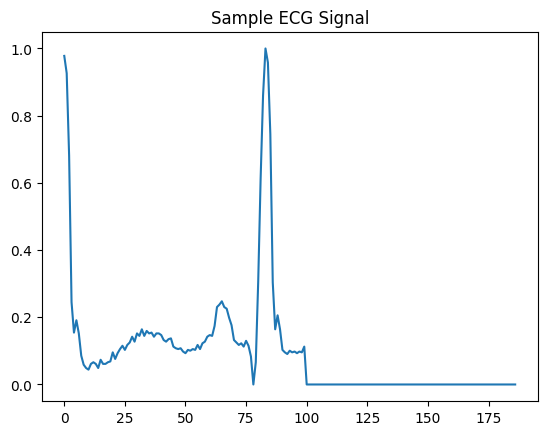

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

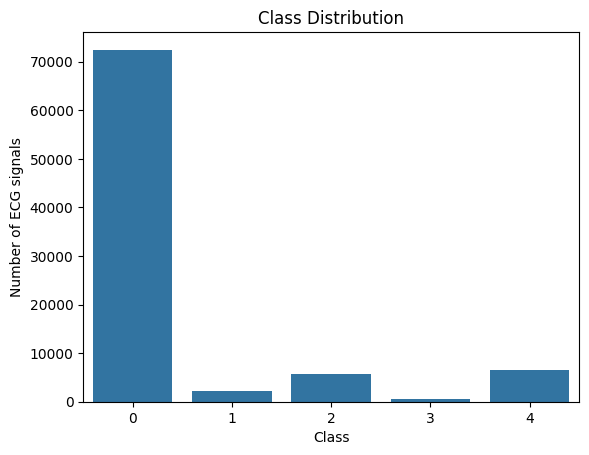

In [6]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [7]:
print("Missing values train:",train.isna().sum().sum())
print("Missing values test:",test.isna().sum().sum())

Missing values train: 0
Missing values test: 0


In [8]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [9]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [10]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [11]:
X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [12]:
def focal_tversky_loss(y_true, y_pred):

    alpha = 0.7
    beta = 0.3
    gamma = 0.75
    smooth = 1e-7

    y_true = tf.cast(y_true, tf.float32)

    TP = tf.reduce_sum(y_true * y_pred, axis=1)
    FP = tf.reduce_sum((1 - y_true) * y_pred, axis=1)
    FN = tf.reduce_sum(y_true * (1 - y_pred), axis=1)

    tversky = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)

    return tf.reduce_mean(tf.pow((1 - tversky), gamma))


def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=focal_tversky_loss,
        metrics=['accuracy']
    )

    return model

In [13]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 405s 103ms/step - accuracy: 0.2072 - loss: nan
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 435s 102ms/step - accuracy: 0.2000 - loss: nan
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 440s 101ms/step - accuracy: 0.2000 - loss: nan
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 438s 100ms/step - accuracy: 0.2000 - loss: nan
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 367s 97ms/step - accuracy: 0.2000 - loss: nan

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 377s 98ms/step - accuracy: 0.2037 - loss: nan
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 390s 100ms/step - accuracy: 0.2001 - loss: nan
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 376s 99ms/step - accuracy: 0.2001 - loss: nan
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 375s 99ms/step - accuracy: 0.2001 - loss: nan
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 381s 101ms/step - accuracy: 0.2001 - loss: nan

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 383s 99ms/step - accuracy: 0.2058 - loss: nan
Epoch 2/5
377

In [14]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [15]:
model = mobilenet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final,y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 498s 108ms/step - accuracy: 0.2081 - loss: nan - val_accuracy: 0.1996 - val_loss: nan
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 475s 105ms/step - accuracy: 0.2001 - loss: nan - val_accuracy: 0.1996 - val_loss: nan
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 470s 104ms/step - accuracy: 0.2001 - loss: nan - val_accuracy: 0.1996 - val_loss: nan
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 468s 103ms/step - accuracy: 0.2001 - loss: nan - val_accuracy: 0.1996 - val_loss: nan
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 479s 106ms/step - accuracy: 0.2001 - loss: nan - val_accuracy: 0.1996 - val_loss: nan
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 526s 111ms/step - accuracy: 0.2001 - loss: nan - val_accuracy: 0.1996 - val_loss: nan
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 486s 107ms/step - accuracy: 0.2001 - loss: nan - val_accuracy: 0.1996 - val_loss: nan
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 490s 108ms/step - accuracy: 0.2001 - loss: nan - val_accuracy:

In [19]:
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax(y_val_final, axis=1)

val_mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", val_mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step
Validation MCC: 0.0


Final Training Accuracy: 0.20011107623577118
Final Validation Accuracy: 0.1995556801557541


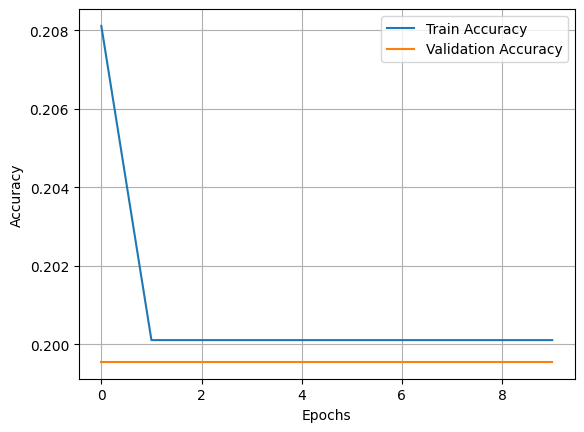

In [20]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

Final Training Loss: nan
Final Validation Loss: nan


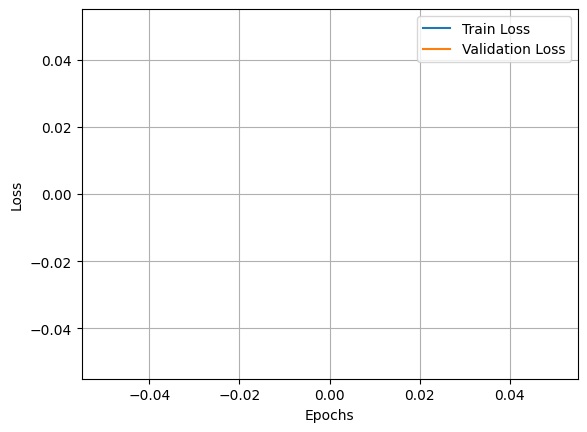

In [21]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

Test Loss: nan
Test Accuracy: 0.8277291655540466
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91     72471
         1.0       0.00      0.00      0.00      2223
         2.0       0.00      0.00      0.00      5788
         3.0       0.00      0.00      0.00       641
         4.0       0.00      0.00      0.00      6431

    accuracy                           0.83     87554
   macro avg       0.17      0.20      0.18     87554
weighted avg       0.69      0.83      0.75     87554



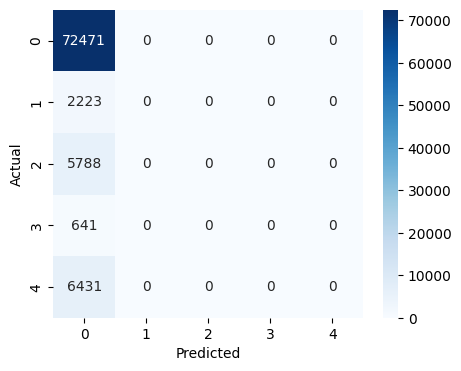

In [23]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()